In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [62]:
data_files = [
    "../data/zstdtrunc-sweep/results.jsonl",
    "../data/sz3-sweep/results.jsonl",
    "../data/sperr-sweep/results.jsonl"
]

relevant_columns_all = [
    'config.branches',
    'config.chunk_size',
    'config.compressor',
    'results.psnr',
    'results.compression_ratio'
]

relevant_columns_trunc = [
    'config.compressor_config.compressionLevel',
    'config.compressor_config.truncBits',
]

relevant_columns_sz3 = [
    'config.compressor_config.cmprAlgo',
    'config.compressor_config.errorBoundMode',
    'config.compressor_config.absErrorBound',
    'config.compressor_config.relErrorBound',
]

relevant_columns_sperr = [
    'config.compressor_config.mode',
    'config.compressor_config.quality',
]

compressor_dfs = {}

for file in data_files:
    raw = pd.read_json(file, lines=True)
    df = pd.json_normalize(raw.to_dict(orient='records'), sep='.')
    compressor = df['config.compressor'].iloc[0]
    if compressor == 'zstd-trunc':
        df = df[relevant_columns_all + relevant_columns_trunc]
    elif compressor == 'sz3':
        df = df[relevant_columns_all + relevant_columns_sz3]
    elif compressor == 'sperr':
        df = df[relevant_columns_all + relevant_columns_sperr]
    compressor_dfs[compressor] = df
    
trunc_df = compressor_dfs['zstd-trunc']
sz3_df = compressor_dfs['sz3'] 
sperr_df = compressor_dfs['sperr']   

# Clear zero distortion values
for compressor, df in compressor_dfs.items():
    df['results.psnr'] = df['results.psnr'].replace(0, float('nan'))
    
# Restrict sz3 results
compressor_dfs['sz3']['config.compressor_config.relErrorBound'] = compressor_dfs['sz3']['config.compressor_config.relErrorBound'].fillna(float('inf')).astype(float)
compressor_dfs['sz3'] = compressor_dfs['sz3'][~(compressor_dfs['sz3']['config.compressor_config.relErrorBound'] > 0.1)]

# Parameter sweep

In [63]:
def pareto_frontier(df, x_col, y_col, x_higher_better=True, y_higher_better=True):
    """
    Compute Pareto-optimal rows for two objectives.
    
    Parameters:
        df: DataFrame
        x_col: Column name for x objective
        y_col: Column name for y objective
        x_higher_better: True if higher x values are better
        y_higher_better: True if higher y values are better
    
    Returns:
        DataFrame of Pareto-optimal rows, sorted by x_col.
    """
    x = df[x_col].values
    y = df[y_col].values
    n = len(x)
    
    is_pareto = np.ones(n, dtype=bool)
    
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            
            if x_higher_better:
                x_ok = x[j] >= x[i]
                x_strict = x[j] > x[i]
            else:
                x_ok = x[j] <= x[i]
                x_strict = x[j] < x[i]
                
            if y_higher_better:
                y_ok = y[j] >= y[i]
                y_strict = y[j] > y[i]
            else:
                y_ok = y[j] <= y[i]
                y_strict = y[j] < y[i]
                
            # j dominates i?
            if x_ok and y_ok and (x_strict or y_strict):
                is_pareto[i] = False
                break
    
    return df[is_pareto].sort_values(x_col, ascending=not x_higher_better)

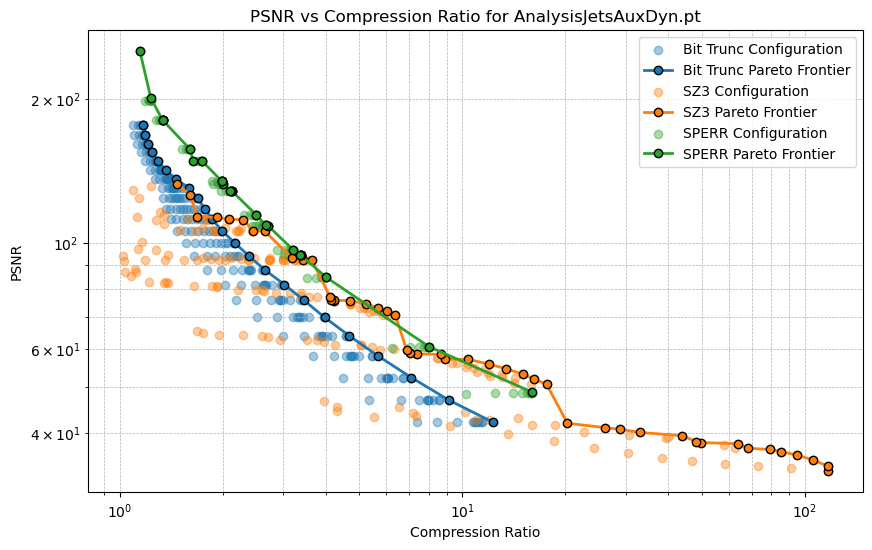

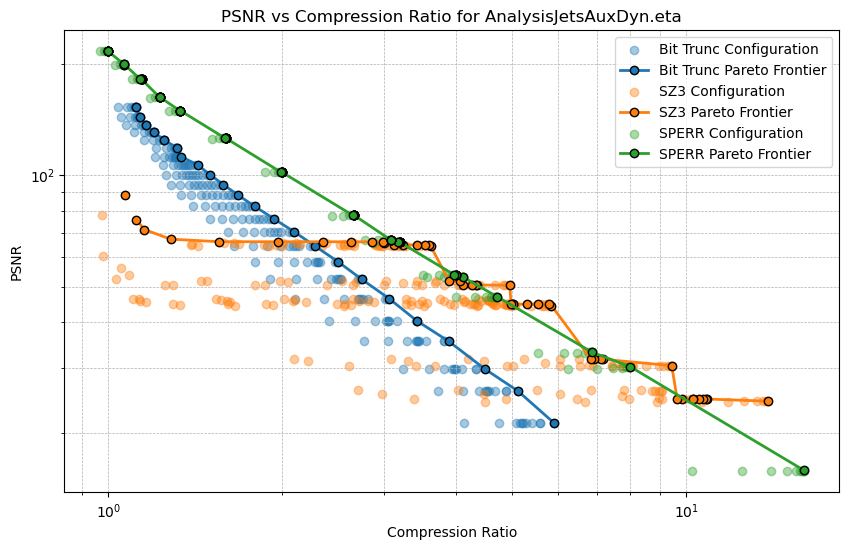

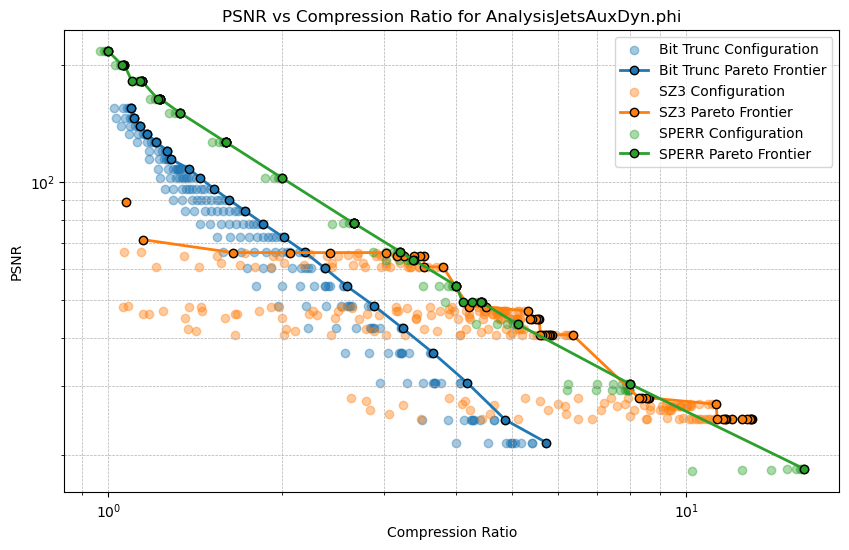

In [ ]:
branches = [
    'AnalysisJetsAuxDyn.pt',
    'AnalysisJetsAuxDyn.eta',
    'AnalysisJetsAuxDyn.phi',
]

compressor_labels = {
    'zstd-trunc': 'Bit Trunc',
    'sz3': 'SZ3',
    'sperr': 'SPERR'
}

frontiers = pd.DataFrame()

for branch in branches:
    plt.figure(figsize=(10, 6))
    for compressor in compressor_dfs.keys():
        subset = compressor_dfs[compressor][compressor_dfs[compressor]['config.branches'] == branch]
        
        # Plot PSNR vs Compression Ratio for all configurations
        plt.scatter(
            subset['results.compression_ratio'], 
            subset['results.psnr'], 
            alpha=0.4,
            label=f'{compressor_labels.get(compressor, compressor)} Configuration'
        )
        
        # Compute Pareto frontier for PSNR vs Compression Ratio
        frontier = pareto_frontier(subset, 'results.compression_ratio', 'results.psnr', x_higher_better=True, y_higher_better=True)
        frontiers = pd.concat([frontiers, frontier.assign(compressor=compressor, branch=branch)], ignore_index=True)
        
        # Plot Pareto frontier
        plt.plot(
            frontier['results.compression_ratio'], 
            frontier['results.psnr'], 
            linewidth=2,
            marker='o', markeredgecolor='black',
            label=f'{compressor_labels.get(compressor, compressor)} Pareto Frontier'
        )

    # plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Compression Ratio')
    plt.ylabel('PSNR')
    plt.title(f'PSNR vs Compression Ratio for {branch}')
    plt.legend()
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.show()

In [65]:
def select_quartile_rows(df):
    col = 'results.psnr'
    clean = df.dropna(subset=[col]).reset_index(drop=False)
    quartiles = clean[col].quantile([0.25, 0.5, 0.75, 1.0])
    idxs = [(clean[col] - q).abs().idxmin() for q in quartiles]
    return clean.loc[idxs]
    
quartile_rows_all = pd.DataFrame()
for compressor in compressor_dfs.keys():
    subset = compressor_dfs[compressor]
    subset = subset[subset['config.branches'] == 'AnalysisJetsAuxDyn.eta']
    quartile_rows = select_quartile_rows(subset)
    quartile_rows_all = pd.concat([quartile_rows_all, quartile_rows])

quartile_rows_all

,index,config.branches,config.chunk_size,config.compressor,results.psnr,results.compression_ratio,config.compressor_config.compressionLevel,config.compressor_config.truncBits,config.compressor_config.cmprAlgo,config.compressor_config.errorBoundMode,config.compressor_config.absErrorBound,config.compressor_config.relErrorBound,config.compressor_config.mode,config.compressor_config.quality
187,462,AnalysisJetsAuxDyn.eta,1024,zstd-trunc,46.388531,2.100967,5,18,NaN,NaN,NaN,NaN,NaN,NaN
121,396,AnalysisJetsAuxDyn.eta,1024,zstd-trunc,82.420670,1.404469,5,12,NaN,NaN,NaN,NaN,NaN,NaN
55,330,AnalysisJetsAuxDyn.eta,1024,zstd-trunc,118.634750,1.207500,5,6,NaN,NaN,NaN,NaN,NaN,NaN
0,275,AnalysisJetsAuxDyn.eta,1024,zstd-trunc,152.892181,1.039809,5,1,NaN,NaN,NaN,NaN,NaN,NaN
266,957,AnalysisJetsAuxDyn.eta,1024,sz3,30.510525,3.404166,NaN,NaN,3,0,0.500000,0.00,NaN,NaN
9,189,AnalysisJetsAuxDyn.eta,4096,sz3,44.890285,2.569107,NaN,NaN,0,1,0.001000,0.01,NaN,NaN
204,893,AnalysisJetsAuxDyn.eta,4096,sz3,51.749550,1.447634,NaN,NaN,2,0,0.050000,0.00,NaN,NaN
235,926,AnalysisJetsAuxDyn.eta,4096,sz3,88.588684,1.071213,NaN,NaN,3,0,0.010000,0.00,NaN,NaN
145,475,AnalysisJetsAuxDyn.eta,4096,sperr,52.957481,3.955332,NaN,NaN,NaN,NaN,NaN,NaN,pwe,0.050000
44,176,AnalysisJetsAuxDyn.eta,1024,sperr,77.818161,2.438079,NaN,NaN,NaN,NaN,NaN,NaN,bpp,12.000000


In [66]:
import subprocess

# Build compressor commands for each selected configuration
commands, results, decomp_files = [], [], []

for _, row in quartile_rows_all.iterrows():
    compressor = row['config.compressor']
    chunk_size = row['config.chunk_size']
    if compressor == 'zstd-trunc':
        level = row['config.compressor_config.compressionLevel']
        trunc_bits = row['config.compressor_config.truncBits']
        compressor_config = f'{compressor}:compressionLevel={level},truncBits={trunc_bits}'
        out_file = f'{compressor}_level{level}_trunc{trunc_bits}.root'
    elif compressor == 'sz3':
        algo = row['config.compressor_config.cmprAlgo']
        ebm = row['config.compressor_config.errorBoundMode']
        aeb = row['config.compressor_config.absErrorBound']
        reb = row['config.compressor_config.relErrorBound']
        compressor_config = f'{compressor}:cmprAlgo={algo},errorBoundMode={ebm},absErrorBound={aeb},relErrorBound={reb}'
        out_file = f'{compressor}_algo{algo}_ebm{ebm}_aeb{aeb}_reb{reb}.root'
    elif compressor == 'sperr':
        mode = row['config.compressor_config.mode']
        quality = row['config.compressor_config.quality']
        compressor_config = f'{compressor}:mode={mode},quality={quality}'
        out_file = f'{compressor}_mode{mode}_quality{quality}.root'
    else:
        continue
    
    decomp_files.append(out_file)
    
    command = [
        "/home/abelo/lossbench/build/lossbench",
        "--inputFile", "/home/abelo/data/DAOD_PHYSLITE.37019878._000009.pool.root.1",
        "--tree", "CollectionTree",
        "--branches", "AnalysisJetsAuxDyn.eta",
        "--chunkSize", str(chunk_size),
        "--compressor", compressor_config,
        "--resultsFile", "/home/abelo/lossbench-experiments/notebooks/results.jsonl",
        "--decompFile", f"/home/abelo/lossbench-experiments/notebooks/{out_file}"
    ]
    
    commands.append(command)


# Clean up
subprocess.run(["rm", "-f", "/home/abelo/lossbench-experiments/notebooks/results.jsonl"], check=True)
for file in decomp_files:
    subprocess.run(["rm", "-f", f"/home/abelo/lossbench-experiments/notebooks/{file}"], check=True)

# Run commands
for cmd in commands:
    print(f"Running: {' '.join(cmd)}")
    subprocess.run(cmd, check=True)

Running: /home/abelo/lossbench/build/lossbench --inputFile /home/abelo/data/DAOD_PHYSLITE.37019878._000009.pool.root.1 --tree CollectionTree --branches AnalysisJetsAuxDyn.eta --chunkSize 1024 --compressor zstd-trunc:compressionLevel=5,truncBits=18 --resultsFile /home/abelo/lossbench-experiments/notebooks/results.jsonl --decompFile /home/abelo/lossbench-experiments/notebooks/zstd-trunc_level5_trunc18.root
Reading data for branch 'AnalysisJetsAuxDyn.eta'...
  Compressing branch 'AnalysisJetsAuxDyn.eta' with compressor 'zstd-trunc' (compressionLevel=5, truncBits=18)...
  Appended results to /home/abelo/lossbench-experiments/notebooks/results.jsonl
  Created /home/abelo/lossbench-experiments/notebooks/zstd-trunc_level5_trunc18.root with branch 'AnalysisJetsAuxDyn.eta'
Running: /home/abelo/lossbench/build/lossbench --inputFile /home/abelo/data/DAOD_PHYSLITE.37019878._000009.pool.root.1 --tree CollectionTree --branches AnalysisJetsAuxDyn.eta --chunkSize 1024 --compressor zstd-trunc:compressi

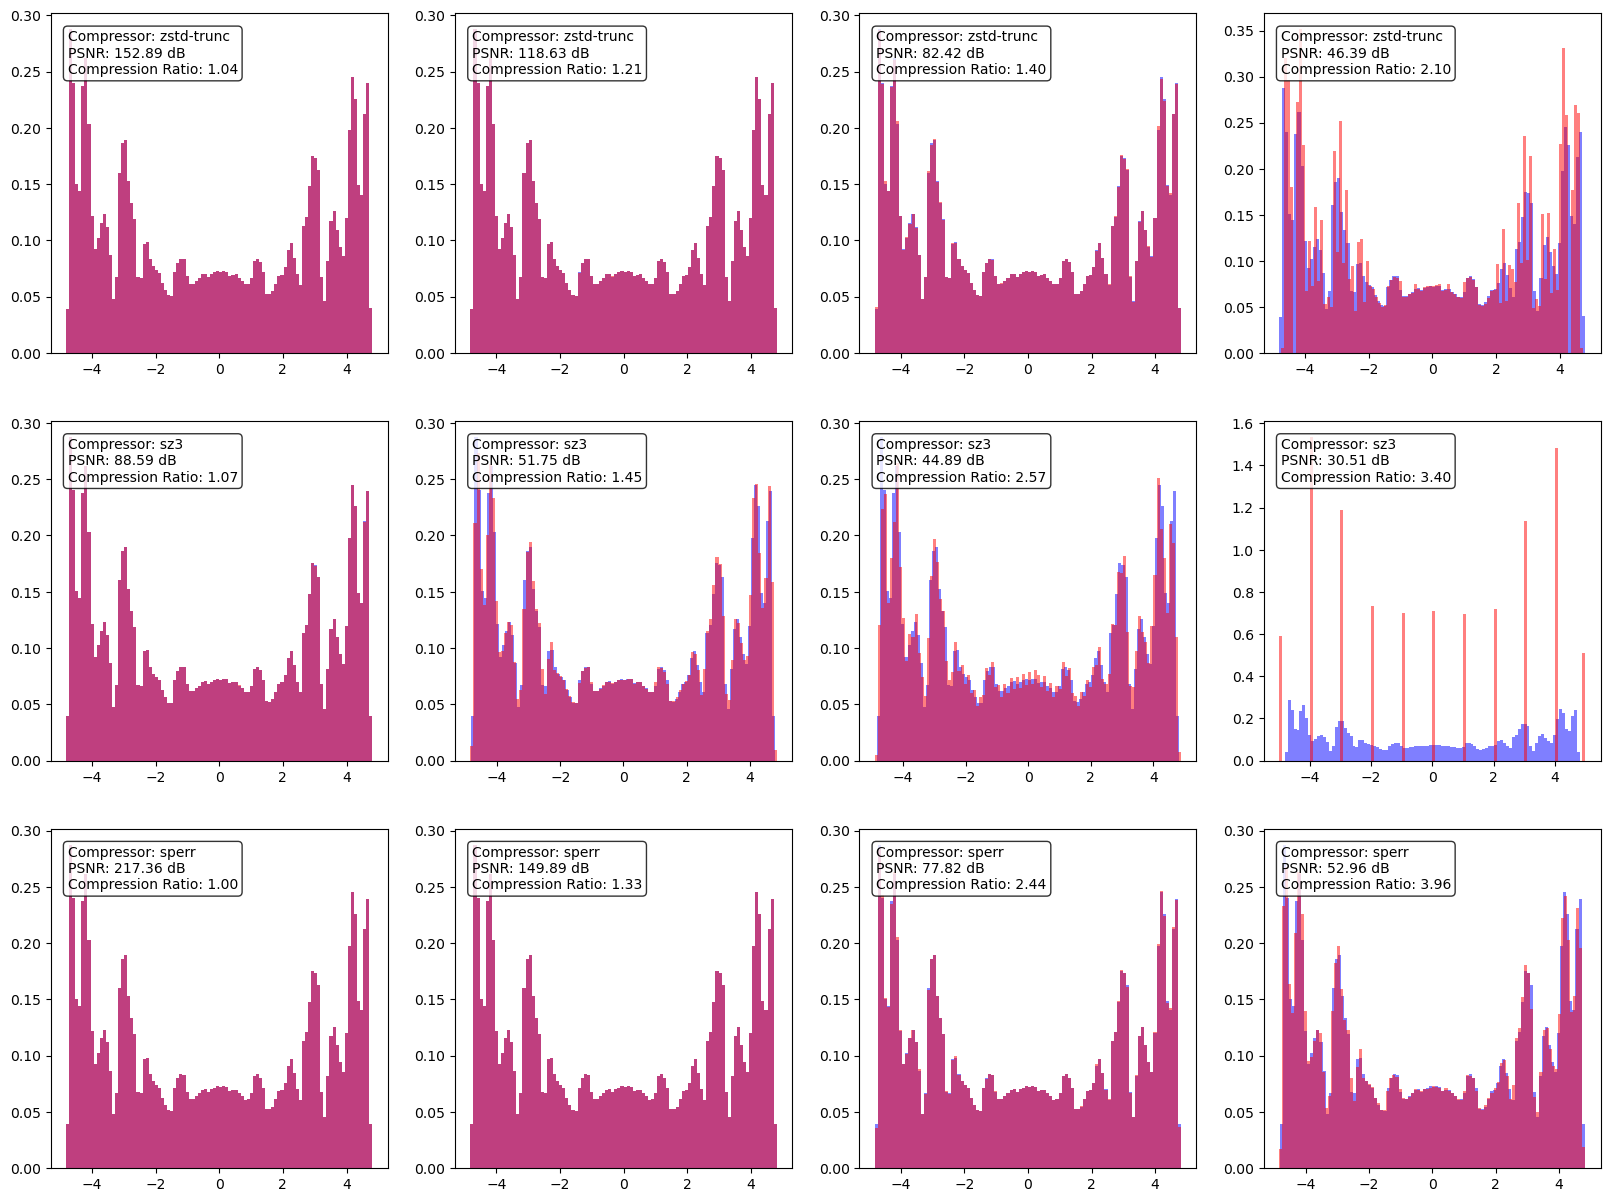

In [79]:
import uproot
import awkward as ak

raw = pd.read_json('results.jsonl', lines=True)
df = pd.json_normalize(raw.to_dict(orient="records"), sep=".")

num_rows = 3
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

# Load original branch data
inputFile = df['config.input_file'].iloc[0]
tree = df['config.tree'].iloc[0]
f = uproot.open(inputFile) 
og_data = f[tree]['AnalysisJetsAuxDyn.eta'].array()

compressors = ['zstd-trunc', 'sz3', 'sperr']
for i in range(num_rows):
    compressor = compressors[i]
    
    # Sort by PSNR within this compressor
    subset = df[df['config.compressor'] == compressor].sort_values('results.psnr', ascending=False)
    
    for j in range(num_cols):
        # axes[i, j].axis('off')

        # Get DataFrame row for this branch and compressor config
        row = subset.iloc[j]
        branch = 'AnalysisJetsAuxDyn.eta'
        
        # Load decompressed data from ROOT file
        decomp_file = row['config.decomp_file']
        f_decomp = uproot.open(decomp_file)
        decomp_data = f_decomp[tree][branch].array()
        
        # Plot original distribution
        axes[i, j].hist(
            ak.flatten(og_data), 
            bins=100, density=True,
            alpha=0.5, color='blue',
            label='Original Distribution'
        )
        
        # Plot decompressed distribution
        axes[i, j].hist(
            ak.flatten(decomp_data), 
            bins=100, density=True,
            alpha=0.5, color='red',
            label='Decompressed Distribution'
        )

        # Add text with config, psnr, and compression ratio
        config_text = f"Compressor: {compressor}\nPSNR: {row['results.psnr']:.2f} dB\nCompression Ratio: {row['results.compression_ratio']:.2f}"
        axes[i, j].text(0.05, 0.95, config_text, transform=axes[i, j].transAxes, fontsize=10,
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
# plt.tight_layout()
# plt.show()